# 9단계. 베이스라인과 모델 교차검증

- 데이터: `data/cache/model_dataset.parquet`(8단계), 확장 창 교차검증 4 fold(블록 2 ~ 5), purge 5거래일
- 타깃: `mdd_low`(연속값). 출력 점수는 D 방식(예측값의 학습 기간 백분위)이다.
- **주 선택 지표: 풀링 Spearman.** 모든 (날짜, 종목) 예측과 실제의 순위 상관이다. D 점수는 날짜를 가리지 않는 전체 순위라서, 이 지표가 점수 품질을 직접 나타낸다.
- 보조 지표:
  - 날짜별 IC(같은 날 종목 순위)
  - 수준 상관(날짜 평균 예측 vs 실제)
  - MAE
  - 위험 상위 10%의 -10% 이상 하락 비율
- 검증 구간(2026-07 ~ 08)은 쓰지 않는다.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.modeling import (FEATURES, STOCK_FEATURES, MARKET_FEATURES, TARGET, LEVEL_FEATURES, VolResidModel,
                          expanding_folds, linear_matrix, evaluate_predictions, calibration_table)
from src import plotting as P

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)
P.setup()

ds = pd.read_parquet(ROOT / "data" / "cache" / "model_dataset.parquet")
folds = expanding_folds(ds)
print(f"표본 {len(ds):,}쌍, fold {[f['fold'] for f in folds]}")

def run(make, name):
    """make(train, test) -> 예측 배열. fold별 OOF 예측과 지표를 돌려준다."""
    oof = []
    for f in folds:
        tr, te = ds.iloc[f["train_idx"]], ds.iloc[f["test_idx"]]
        oof.append(te[["trade_date", "symbol", TARGET, "mdd_close"]].assign(pred=make(tr, te), fold=f["fold"]))
    o = pd.concat(oof)
    e = evaluate_predictions(o)
    r = {"model": name, "pooled_rho": o[["pred", TARGET]].corr("spearman").iloc[0, 1],
         "IC": e["IC"], "IC_IR": e["IC_IR"], "level_corr": e["level_corr"], "level_bias": e["level_bias"],
         "MAE": e["MAE"], "top10_event_rate": e["top10_event_rate"]}
    for k, g in o.groupby("fold"):
        r[f"pooled_f{k}"] = g[["pred", TARGET]].corr("spearman").iloc[0, 1]
    return r, o

표본 107,880쌍, fold [2, 3, 4, 5]


## 1. 후보 비교

In [2]:
def const(tr, te):
    return np.full(len(te), tr[TARGET].mean())

def linear(cols):
    def f(tr, te):
        Xtr, Xte = linear_matrix(tr, te, cols)
        return Ridge(alpha=1.0).fit(Xtr, tr[TARGET]).predict(Xte)
    return f

def ridge_all(tr, te):
    Xtr, Xte = linear_matrix(tr, te, FEATURES)
    return Ridge(alpha=10).fit(Xtr, tr[TARGET]).predict(Xte)

LGB = dict(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=200, subsample=0.8, subsample_freq=1,
           colsample_bytree=0.8, reg_lambda=1.0, verbose=-1)
def lgb_all(tr, te):
    return lgb.LGBMRegressor(**LGB).fit(tr[FEATURES], tr[TARGET]).predict(te[FEATURES])

def vr(**kw):
    return lambda tr, te: VolResidModel(**kw).fit(tr).predict(te)

CANDS = [
    ("B0 상수(학습 평균)", const),
    ("B1 gk_5 선형", linear(["gk_5"])),
    ("B2 변동성 3개 선형", linear(LEVEL_FEATURES)),
    ("M1 Ridge 전체 변수", ridge_all),
    ("M2 LightGBM 전체 변수", lgb_all),
    ("M3 변동성 수준 + 횡단면 잔차 LGB", vr()),
]
results, oofs = [], {}
for name, fn in CANDS:
    r, o = run(fn, name)
    results.append(r)
    oofs[name] = o
cand = pd.DataFrame(results).set_index("model")
cand.round(4)

,pooled_rho,IC,IC_IR,level_corr,level_bias,MAE,top10_event_rate,pooled_f2,pooled_f3,pooled_f4,pooled_f5
model,,,,,,,,,,,
B0 상수(학습 평균),-0.1154,NaN,NaN,-0.2704,0.0040,0.0317,0.0678,NaN,NaN,NaN,NaN
B1 gk_5 선형,0.2987,0.3159,1.9203,0.3716,0.0013,0.0299,0.3055,0.2458,0.2545,0.2622,0.2867
B2 변동성 3개 선형,0.3108,0.3226,1.8358,0.4223,0.0009,0.0298,0.3116,0.2477,0.2949,0.2673,0.3034
M1 Ridge 전체 변수,0.2274,0.3338,1.7115,0.0147,-0.0019,0.0320,0.1988,0.2823,0.3457,0.2112,0.2774
M2 LightGBM 전체 변수,0.2795,0.3319,1.7610,0.3315,-0.0076,0.0324,0.3225,0.3214,0.2609,0.1280,0.3665
M3 변동성 수준 + 횡단면 잔차 LGB,0.3202,0.3385,1.7647,0.4220,0.0009,0.0296,0.3056,0.2790,0.3106,0.2693,0.3065


## 2. 제거 실험 (M3 기준)

M3의 구성 요소를 하나씩 바꿔 가며 기여도를 본다.

In [3]:
FLOW = ["margin_rate", "lend_days_20", "pension_net_20", "indiv_net_20", "prog_nonarb_net_20", "foreign_hold"]
ABL = [
    ("M3 기본", vr()),
    ("수준 변수 gk_5만", vr(level_features=["gk_5"])),
    ("횡단면: 수급·신용·대차 제외", vr(cs_features=[c for c in STOCK_FEATURES if c not in FLOW])),
    ("횡단면: downside_ratio_20 제외", vr(cs_features=[c for c in STOCK_FEATURES if c != "downside_ratio_20"])),
    ("횡단면: 변동성 변수만", vr(cs_features=["gk_5", "idio_vol_60", "ind_vol_20"])),
    ("트리 100개", vr(lgb_params={"n_estimators": 100})),
    ("트리 400개", vr(lgb_params={"n_estimators": 400})),
    ("잎 31개", vr(lgb_params={"num_leaves": 31})),
]
abl = pd.DataFrame([run(fn, name)[0] for name, fn in ABL]).set_index("model")
abl.round(4)

,pooled_rho,IC,IC_IR,level_corr,level_bias,MAE,top10_event_rate,pooled_f2,pooled_f3,pooled_f4,pooled_f5
model,,,,,,,,,,,
M3 기본,0.3202,0.3385,1.7647,0.4220,0.0009,0.0296,0.3056,0.2790,0.3106,0.2693,0.3065
수준 변수 gk_5만,0.3113,0.3340,1.7182,0.3716,0.0013,0.0296,0.3057,0.2760,0.2859,0.2720,0.2963
횡단면: 수급·신용·대차 제외,0.3194,0.3376,1.7825,0.4220,0.0009,0.0296,0.3016,0.2823,0.3049,0.2698,0.3063
횡단면: downside_ratio_20 제외,0.3200,0.3379,1.7608,0.4220,0.0009,0.0296,0.3050,0.2794,0.3090,0.2696,0.3071
횡단면: 변동성 변수만,0.3130,0.3276,1.7835,0.4220,0.0009,0.0297,0.3110,0.2643,0.2999,0.2639,0.3017
트리 100개,0.3213,0.3393,1.7816,0.4220,0.0009,0.0296,0.3119,0.2801,0.3109,0.2712,0.3063
트리 400개,0.3164,0.3346,1.7448,0.4220,0.0009,0.0297,0.2990,0.2731,0.3071,0.2654,0.3055
잎 31개,0.3174,0.3359,1.7577,0.4220,0.0009,0.0296,0.3007,0.2745,0.3058,0.2675,0.3080


## 3. 점수 신뢰성: 예측 분위별 실제 낙폭 (교차검증 예측 전체, 10 = 가장 위험)

In [4]:
BEST = "M3 변동성 수준 + 횡단면 잔차 LGB"
cal_best = calibration_table(oofs[BEST])
cal_b1 = calibration_table(oofs["B1 gk_5 선형"])
display(cal_best.round(4).assign(모델="M3"))
display(cal_b1.round(4).assign(모델="B1"))
mono = lambda c: pd.Series(c.bucket.astype(int)).corr(c.actual_mean, method="spearman")
print("분위와 실제 평균 낙폭의 순위상관(-1이면 완전 단조): M3", round(mono(cal_best), 3), "| B1", round(mono(cal_b1), 3))

,bucket,pred_mean,actual_mean,event_rate,n,모델
0,1,-0.0217,-0.0227,0.0127,8633,M3
1,2,-0.0275,-0.0282,0.0188,8633,M3
2,3,-0.0312,-0.0322,0.0323,8633,M3
3,4,-0.0346,-0.0341,0.0383,8633,M3
4,5,-0.0381,-0.0376,0.0529,8633,M3
5,6,-0.0419,-0.0417,0.0750,8632,M3
6,7,-0.0462,-0.0458,0.0989,8633,M3
7,8,-0.0514,-0.0533,0.1449,8633,M3
8,9,-0.0585,-0.0601,0.1960,8633,M3
9,10,-0.0726,-0.0769,0.3056,8633,M3


,bucket,pred_mean,actual_mean,event_rate,n,모델
0,1,-0.0273,-0.0244,0.0166,8633,B1
1,2,-0.0311,-0.0291,0.0220,8633,B1
2,3,-0.0335,-0.0322,0.0332,8633,B1
3,4,-0.0357,-0.0353,0.0464,8633,B1
4,5,-0.0380,-0.0377,0.0550,8633,B1
5,6,-0.0406,-0.0415,0.0728,8632,B1
6,7,-0.0437,-0.0468,0.1046,8633,B1
7,8,-0.0476,-0.0501,0.1296,8633,B1
8,9,-0.0536,-0.0587,0.1897,8633,B1
9,10,-0.0679,-0.0769,0.3055,8633,B1


분위와 실제 평균 낙폭의 순위상관(-1이면 완전 단조): M3 -1.0 | B1 -1.0


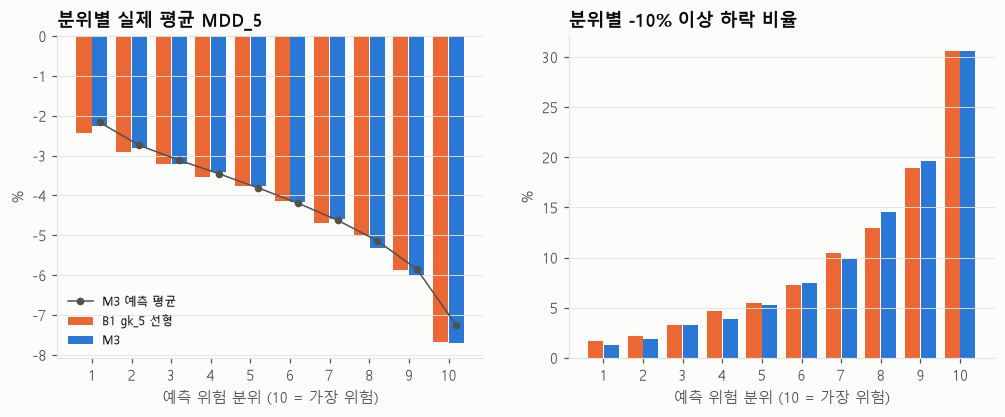

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
x = np.arange(1, 11)
for ax, col, title in [(axes[0], "actual_mean", "분위별 실제 평균 MDD_5"), (axes[1], "event_rate", "분위별 -10% 이상 하락 비율")]:
    ax.bar(x - 0.2, cal_b1[col] * 100, width=0.38, color=P.SERIES[1], label="B1 gk_5 선형")
    ax.bar(x + 0.2, cal_best[col] * 100, width=0.38, color=P.SERIES[0], label="M3")
    ax.set_xticks(x)
    ax.set_xlabel("예측 위험 분위 (10 = 가장 위험)")
    ax.set_ylabel("%")
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
axes[0].plot(x + 0.2, cal_best["pred_mean"] * 100, color=P.TEXT_2, marker="o", ms=4, lw=1, label="M3 예측 평균")
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
P.save(fig, "09_calibration")
plt.show()

## 4. 시장 수준 추적: 날짜별 평균 예측 vs 실제 (교차검증 예측)

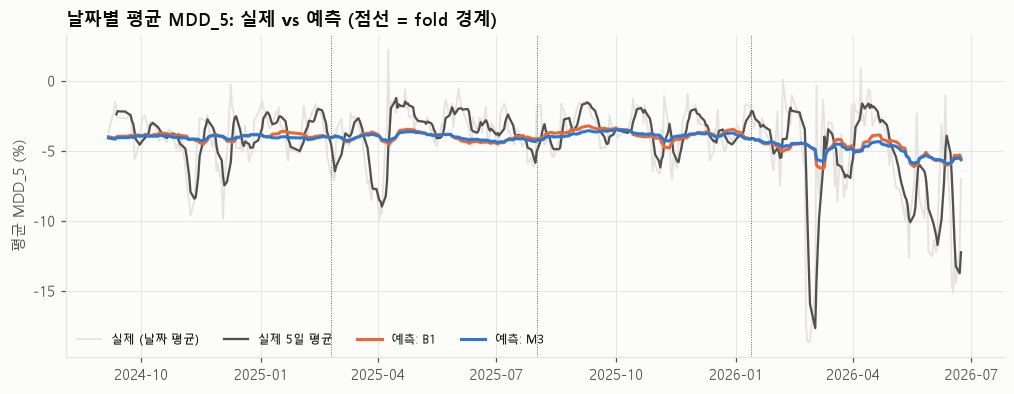

fold 5 날짜 평균: 실제 -0.0606 | 예측 M3 -0.0496 | 예측 B1 -0.0491


In [6]:
fig, ax = plt.subplots(figsize=(11, 3.8))
act = oofs[BEST].groupby("trade_date")[TARGET].mean()
ax.plot(act.index, act * 100, color=P.GRID, lw=1.2, label="실제 (날짜 평균)")
ax.plot(act.rolling(5).mean().index, act.rolling(5).mean() * 100, color=P.TEXT_2, lw=1.5, label="실제 5일 평균")
for name, col in [("B1 gk_5 선형", P.SERIES[1]), (BEST, P.SERIES[0])]:
    pm = oofs[name].groupby("trade_date")["pred"].mean()
    ax.plot(pm.index, pm * 100, color=col, lw=2, label=f"예측: {name.split(' ')[0]}")
for f in folds[1:]:
    ax.axvline(ds.iloc[f["test_idx"]].trade_date.min(), color=P.TEXT_2, lw=0.6, ls=":")
ax.set_ylabel("평균 MDD_5 (%)")
ax.set_title("날짜별 평균 MDD_5: 실제 vs 예측 (점선 = fold 경계)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(frameon=False, fontsize=8, ncol=4, loc="lower left")
P.save(fig, "09_level_tracking")
plt.show()
f5 = oofs[BEST][oofs[BEST].fold == 5]
print("fold 5 날짜 평균: 실제", round(f5[TARGET].mean(), 4), "| 예측 M3", round(f5.pred.mean(), 4),
      "| 예측 B1", round(oofs["B1 gk_5 선형"].query("fold == 5").pred.mean(), 4))

## 5. 횡단면 모델의 변수 중요도 (학습 구간 전체로 학습, gain 비율)

In [7]:
m_all = VolResidModel().fit(ds)
imp = pd.Series(m_all.cs_.booster_.feature_importance("gain"), index=m_all.cs_features)
display((imp / imp.sum()).sort_values(ascending=False).round(3).to_frame("gain 비율"))
coef = pd.Series(m_all.level_.coef_, index=m_all.level_features)
print("수준 모델 계수(표준화 변수 기준):", coef.round(4).to_dict(), "| 절편", round(float(m_all.level_.intercept_), 4))

,gain 비율
gk_5,0.085
idio_vol_60,0.075
pos_20,0.075
beta_60,0.074
margin_rate,0.065
n_down3_60,0.064
foreign_hold,0.062
log_mcap,0.058
skew_60,0.047
min_intra_drop_20,0.047


수준 모델 계수(표준화 변수 기준): {'gk_5': -0.0087, 'idio_vol_60': -0.0071, 'ind_vol_20': -0.002} | 절편 -0.0427


## 6. 저장

In [8]:
oofs[BEST].to_parquet(ROOT / "data" / "cache" / "oof_m3.parquet", index=False)
pd.concat([cand, abl]).to_csv(ROOT / "outputs" / "model_cv_results.csv", encoding="utf-8-sig")
print("저장: data/cache/oof_m3.parquet, outputs/model_cv_results.csv")

저장: data/cache/oof_m3.parquet, outputs/model_cv_results.csv


## 7. 결론

**선택: M3(변동성 수준 + 횡단면 잔차 LightGBM)**
- 풀링 Spearman 0.320으로 가장 높다(B1 0.299, B2 0.311).
  - 날짜별 IC: 0.339(B1 0.316)
  - 수준 상관: 0.42(B1 0.37)
  - MAE: 0.0296(B1 0.0299)
- fold별로 보면 4개 중 3개에서 B1보다 낫고, fold 4에서도 거의 같다(0.269 vs 0.262).
- 전체 변수를 한 모델에 넣은 M1(Ridge)과 M2(LightGBM)는 IC는 비슷하지만 **수준 예측이 fold마다 불안정해서**(M1 수준 상관 0.01, M2 fold 4 풀링 0.13) 풀링 성능이 떨어졌다.
- **최종 설정은 트리 100개**로 한다. 기본 200개와 차이가 거의 없는데(0.3213 vs 0.3202) 더 단순하다.

**점수 신뢰성**
- 예측 분위가 올라갈수록 실제 평균 낙폭이 단조롭게 커진다(순위상관 -1.0).
- 예측 평균과 실제 평균도 가깝다. 최상위 분위는 예측 -7.3%, 실제 -7.7%이고, 이 분위의 -10% 이상 하락 비율은 30.6%(전체 평균 약 9%)다.

**제거 실험**
- 수준 변수를 `gk_5` 하나로 줄이면 성능이 떨어진다(0.311).
- 횡단면 모델에서 변동성 외 변수를 모두 빼면 0.313으로 떨어진다. 하방 특성, 가격 위치, 베타, 신용잔고 등이 기여한다.
- 수급·신용·대차 변수 6개를 빼도 거의 같다(0.319). 기여가 작다.
- `downside_ratio_20`은 빼도 차이가 없다.

**한계: 시장 수준 충격은 미리 예측하지 못한다**
- 예측의 날짜 평균은 -4 ~ -6% 사이에서 완만하게 움직인다.
- 2026년 3월(실제 평균 약 -18%)처럼 갑작스러운 시장 충격은 미리 반영하지 못한다. 변동성이 오른 **뒤에야** 예측 수준이 따라 올라간다.
- fold 5 평균: 실제 -6.1%, 예측 -5.0%. 충격 국면을 약 1%p 과소평가했다.
- 따라서 D 점수는 **종목 간 상대 위험과 변동성 국면은 잘 반영하지만, 급락 직전의 경보 역할은 하지 못한다.** 이 한계를 점수와 함께 명시해야 한다.